# Notebook 04 — Storytelling Visual: DRE, Margens e Riscos
**Projeto:** Análise de Custos e Margem por Categoria — Olist E-Commerce
**Autor:** Ariel Marquezin
**Stack:** Matplotlib · Seaborn · pandas

In [ ]:
!pip install matplotlib seaborn pandas pyarrow -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
import pyarrow.parquet as pq

# ── Estilo global legível ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : '#0d1117',
    'axes.facecolor'    : '#161b22',
    'axes.edgecolor'    : '#8b949e',
    'axes.labelcolor'   : '#ffffff',
    'axes.titlecolor'   : '#ffffff',
    'xtick.color'       : '#ffffff',
    'ytick.color'       : '#ffffff',
    'text.color'        : '#ffffff',
    'grid.color'        : '#30363d',
    'grid.linestyle'    : '--',
    'grid.alpha'        : 0.5,
    'font.family'       : 'monospace',
    'font.size'         : 12,
    'axes.titlesize'    : 15,
    'axes.labelsize'    : 13,
    'xtick.labelsize'   : 11,
    'ytick.labelsize'   : 11,
    'legend.fontsize'   : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

C_CYAN   = '#00e5ff'
C_GREEN  = '#10b981'
C_YELLOW = '#f59e0b'
C_RED    = '#ef4444'
C_PURPLE = '#7c3aed'
C_BLUE   = '#3b82f6'
C_GRAY   = '#4a5568'

GOLD_PATH    = '/content/drive/MyDrive/olist/gold/'
FIGURES_PATH = '/content/drive/MyDrive/olist/figures/'
os.makedirs(FIGURES_PATH, exist_ok=True)
print('Estilo configurado OK')

Estilo configurado OK


In [ ]:
def load(name):
    return pq.read_table(os.path.join(GOLD_PATH, f'{name}.parquet')).to_pandas()

dre     = load('dre_por_categoria')
pareto  = load('pareto_receita')
monthly = load('tendencia_mensal')
risk    = load('matriz_risco')
metrics = load('metricas_pedidos')
print('Dados carregados OK')

Dados carregados OK


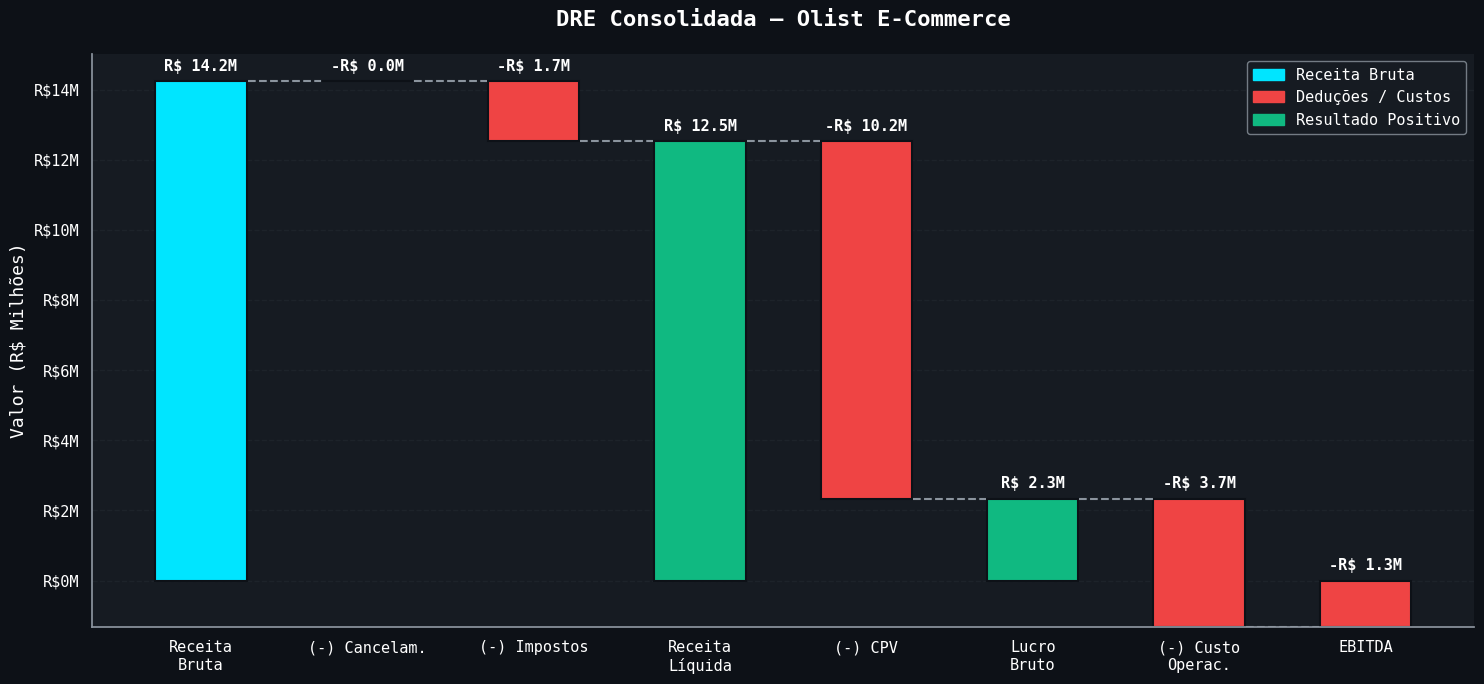

Figura 1 salva


In [ ]:
# ── FIGURA 1: Waterfall DRE ───────────────────────────────────────────────────
labels = [
    'Receita\nBruta', '(-) Cancelam.', '(-) Impostos',
    'Receita\nLíquida', '(-) CPV', 'Lucro\nBruto',
    '(-) Custo\nOperac.', 'EBITDA'
]
raw_values = [
     dre['receita_bruta'].sum(),
    -dre['deducoes_cancelamentos'].sum(),
    -dre['impostos'].sum(),
     dre['receita_liquida'].sum(),
    -dre['cpv'].sum(),
     dre['lucro_bruto'].sum(),
    -dre['custo_operacional'].sum(),
     dre['ebitda'].sum()
]

TOTALS_IDX = {0, 3, 5, 7}
bottoms, bar_vals, colors = [], [], []
running = 0

for i, v in enumerate(raw_values):
    if i in TOTALS_IDX:
        bottoms.append(min(0, running))
        bar_vals.append(abs(running) if i != 0 else v)
        if i == 0:
            running = v
            colors.append(C_CYAN)
        elif running >= 0:
            colors.append(C_GREEN)
        else:
            colors.append(C_RED)
    else:
        if v < 0:
            bottoms.append(running + v)
        else:
            bottoms.append(running)
        bar_vals.append(abs(v))
        colors.append(C_RED if v < 0 else C_GREEN)
        running += v

fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

bars = ax.bar(labels, bar_vals, bottom=bottoms, color=colors,
              width=0.55, edgecolor='#0d1117', linewidth=1.5)

# Linha de conexão entre barras
for i in range(len(labels) - 1):
    if raw_values[i] >= 0:
        y_connect = bottoms[i] + bar_vals[i]  # topo da barra positiva
    else:
        y_connect = bottoms[i]                 # base da barra negativa
    ax.plot([i + 0.28, i + 0.72], [y_connect, y_connect],
            color='#8b949e', linewidth=1.5, linestyle='--')

# Anotações com valor + sinal claro
for i, (b, bv, rv) in enumerate(zip(bottoms, bar_vals, raw_values)):
    val = rv
    sign = '-' if val < 0 else ''
    txt = f'{sign}R$ {abs(val)/1e6:.1f}M'
    y_pos = b + bv + abs(raw_values[0]) * 0.015
    ax.text(i, y_pos, txt, ha='center', va='bottom',
            fontsize=11, color='white', fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.0f}M'))
ax.set_title('DRE Consolidada — Olist E-Commerce', fontsize=16, fontweight='bold',
             color='white', pad=20)
ax.set_ylabel('Valor (R$ Milhões)', fontsize=13, color='white')
ax.tick_params(axis='x', labelsize=11, colors='white')
ax.tick_params(axis='y', labelsize=11, colors='white')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

legend_elements = [
    mpatches.Patch(color=C_CYAN,  label='Receita Bruta'),
    mpatches.Patch(color=C_RED,   label='Deduções / Custos'),
    mpatches.Patch(color=C_GREEN, label='Resultado Positivo'),
]
ax.legend(handles=legend_elements, loc='upper right',
          facecolor='#161b22', edgecolor='#8b949e', fontsize=11,
          labelcolor='white')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '01_waterfall_dre.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura 1 salva')

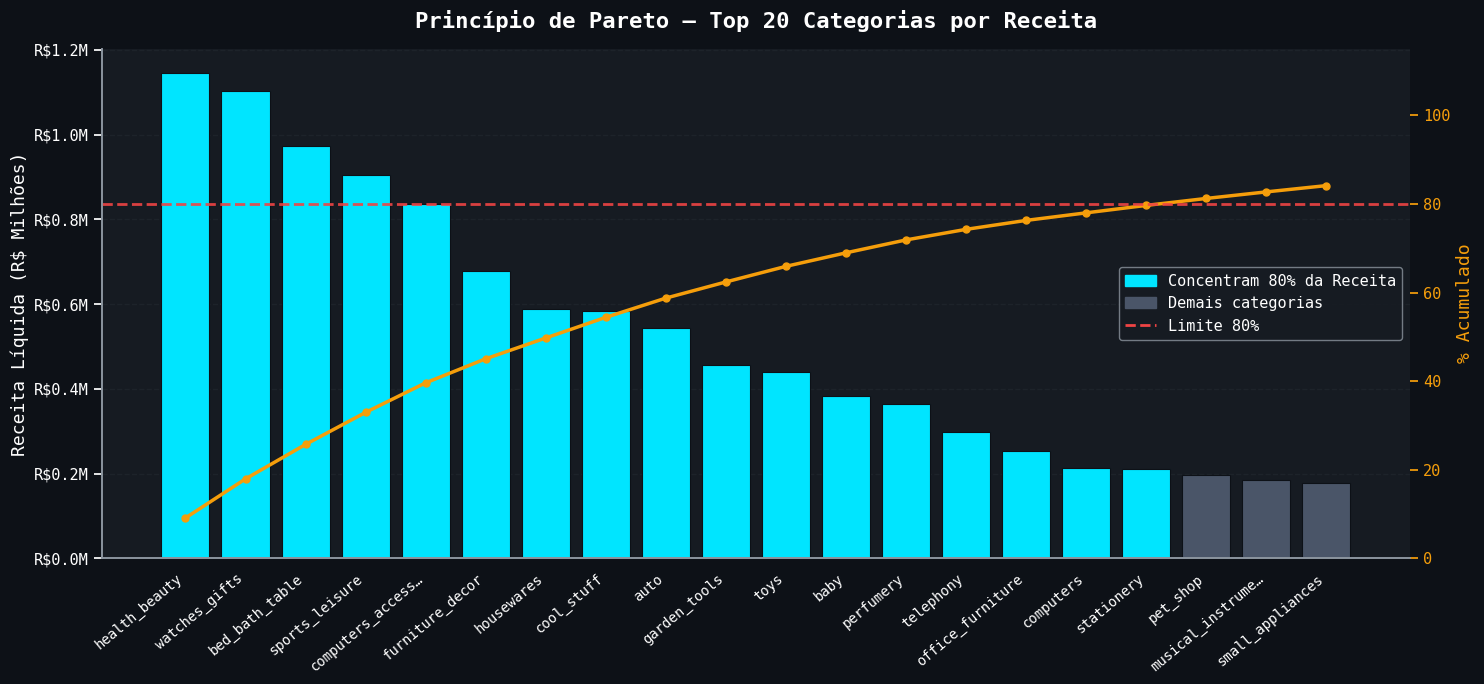

Figura 2 salva


In [ ]:
# ── FIGURA 2: Pareto ──────────────────────────────────────────────────────────
top_n  = min(20, len(pareto))
df_p   = pareto.head(top_n).copy()

fig, ax1 = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#0d1117')
ax1.set_facecolor('#161b22')

bar_colors = [C_CYAN if row['participacao_acumulada_pct'] <= 80 else C_GRAY
              for _, row in df_p.iterrows()]
ax1.bar(range(top_n), df_p['receita_liquida'] / 1e6,
        color=bar_colors, edgecolor='#0d1117', linewidth=0.8)

ax2 = ax1.twinx()
ax2.set_facecolor('#161b22')
ax2.plot(range(top_n), df_p['participacao_acumulada_pct'],
         color=C_YELLOW, linewidth=2.5, marker='o', markersize=5)
ax2.axhline(80, color=C_RED, linestyle='--', linewidth=2, alpha=0.9, label='80%')
ax2.set_ylim(0, 115)
ax2.set_ylabel('% Acumulado', color=C_YELLOW, fontsize=13)
ax2.tick_params(colors=C_YELLOW, labelsize=11)

cats = [c[:16] + '…' if len(c) > 16 else c for c in df_p['category']]
ax1.set_xticks(range(top_n))
ax1.set_xticklabels(cats, rotation=40, ha='right', fontsize=10, color='white')
ax1.set_ylabel('Receita Líquida (R$ Milhões)', fontsize=13, color='white')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M'))
ax1.tick_params(axis='y', labelsize=11, colors='white')
ax1.set_title(f'Princípio de Pareto — Top {top_n} Categorias por Receita',
              fontsize=16, fontweight='bold', color='white', pad=15)
ax1.grid(axis='y', alpha=0.3)
ax1.set_axisbelow(True)

legend_elems = [
    mpatches.Patch(color=C_CYAN, label='Concentram 80% da Receita'),
    mpatches.Patch(color=C_GRAY, label='Demais categorias'),
    plt.Line2D([0],[0], color=C_RED, linestyle='--', linewidth=2, label='Limite 80%'),
]
ax1.legend(handles=legend_elems, loc='center right',
           facecolor='#161b22', edgecolor='#8b949e', fontsize=11, labelcolor='white')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '02_pareto_receita.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura 2 salva')

In [ ]:
!pip install adjustText -q

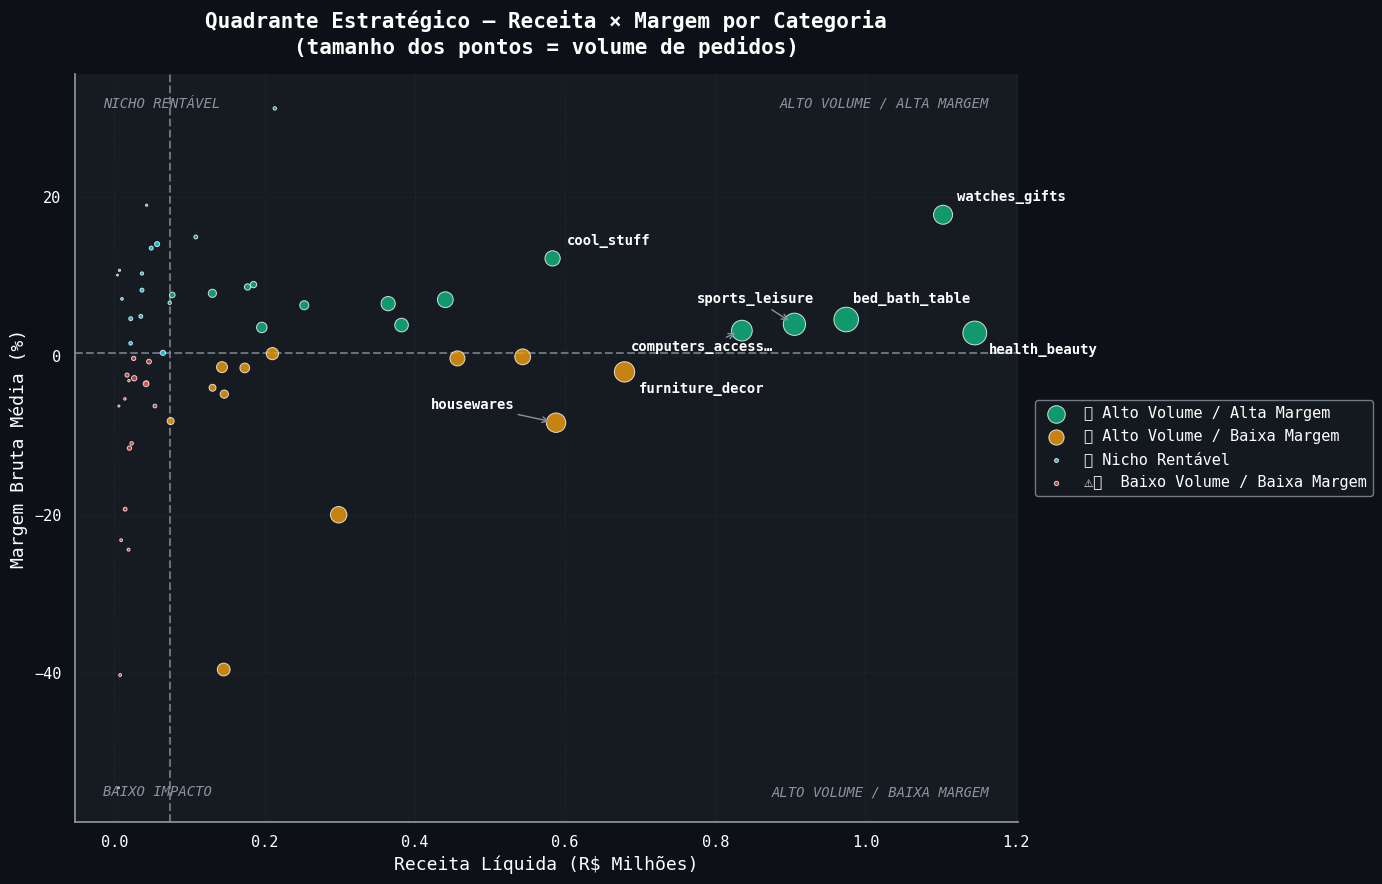

Figura 3 salva


In [ ]:
# ── FIGURA 3: Quadrante Estratégico ──────────────────────────────────────────
from matplotlib.text import Annotation

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

x_med = dre['receita_liquida'].median()
y_med = dre['margem_bruta_media_pct'].median()

quad_colors = {
    '⭐ Alto Volume / Alta Margem'   : C_GREEN,
    '📦 Alto Volume / Baixa Margem'  : C_YELLOW,
    '💎 Nicho Rentável'              : C_CYAN,
    '⚠️  Baixo Volume / Baixa Margem': C_RED,
}
for quad, color in quad_colors.items():
    mask   = dre['quadrant'] == quad
    subset = dre[mask]
    ax.scatter(
        subset['receita_liquida'] / 1e6,
        subset['margem_bruta_media_pct'],
        s=subset['total_orders'] / 30,
        color=color, alpha=0.8,
        edgecolors='white', linewidths=0.7,
        label=quad, zorder=3
    )

# Offsets manuais por categoria para evitar sobreposição
offsets = {
    'watches_gifts'     : ( 10,  10),
    'health_beauty'     : ( 10, -15),
    'bed_bath_table'    : (  5,  12),
    'sports_leisure'    : (-70,  15),
    'computers_access…' : (-80, -15),
    'cool_stuff'        : ( 10,  10),
    'furniture_decor'   : ( 10, -15),
    'housewares'        : (-90,  10),
}

top_labels = dre.nlargest(8, 'receita_liquida')
for _, row in top_labels.iterrows():
    cat = row['category'][:16] + '…' if len(row['category']) > 16 else row['category']
    dx, dy = offsets.get(cat, (10, 5))
    # Só desenha seta se o offset for grande
    use_arrow = abs(dx) > 20 or abs(dy) > 20
    props = dict(arrowstyle='->', color='#8b949e', lw=1.0,
                 shrinkA=0, shrinkB=5) if use_arrow else None
    ax.annotate(cat,
                xy=(row['receita_liquida']/1e6, row['margem_bruta_media_pct']),
                xytext=(dx, dy), textcoords='offset points',
                fontsize=10, color='white', fontweight='bold',
                arrowprops=props)

# Ajuste automático de sobreposição
try:
    from adjustText import adjust_text
    adjust_text(texts, ax=ax,
                expand_points=(1.5, 1.5),
                expand_text=(1.5, 1.5),
                arrowprops=None)
except ImportError:
    pass

ax.axvline(x_med / 1e6, color='#8b949e', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(y_med,       color='#8b949e', linestyle='--', linewidth=1.5, alpha=0.7)

for txt, xy, ha, va in [
    ('ALTO VOLUME / ALTA MARGEM',  (0.97, 0.97), 'right', 'top'),
    ('ALTO VOLUME / BAIXA MARGEM', (0.97, 0.03), 'right', 'bottom'),
    ('NICHO RENTÁVEL',             (0.03, 0.97), 'left',  'top'),
    ('BAIXO IMPACTO',              (0.03, 0.03), 'left',  'bottom'),
]:
    ax.text(*xy, txt, transform=ax.transAxes, fontsize=10,
            color='#8b949e', va=va, ha=ha, fontstyle='italic')

ax.set_xlabel('Receita Líquida (R$ Milhões)', fontsize=13, color='white')
ax.set_ylabel('Margem Bruta Média (%)', fontsize=13, color='white')
ax.set_title('Quadrante Estratégico — Receita × Margem por Categoria\n(tamanho dos pontos = volume de pedidos)',
             fontsize=15, fontweight='bold', color='white', pad=15)
ax.tick_params(labelsize=11, colors='white')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
          facecolor='#161b22', edgecolor='#8b949e', fontsize=11, labelcolor='white')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '03_quadrante_estrategico.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura 3 salva')

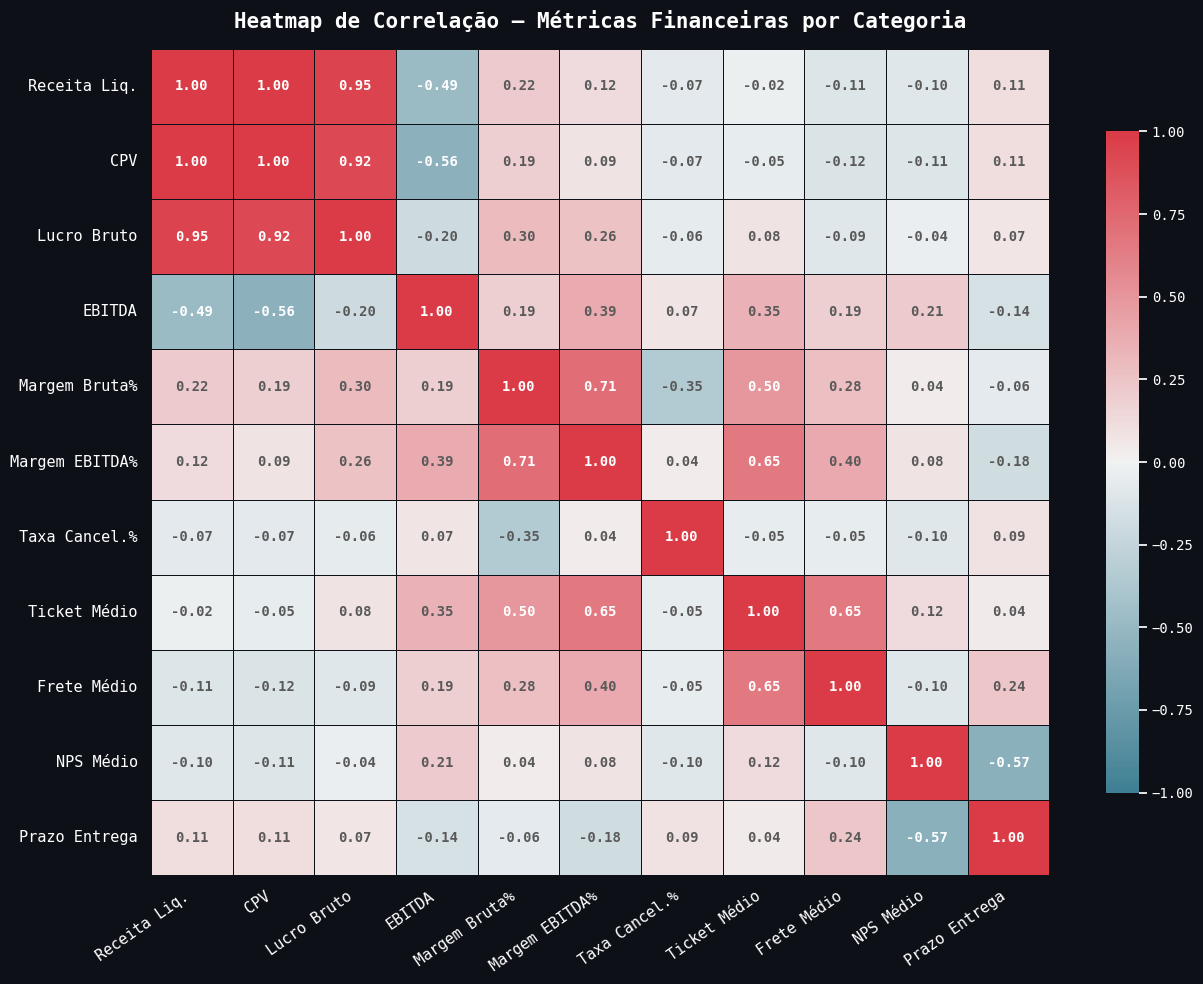

Figura 4 salva


In [ ]:
# ── FIGURA 4: Heatmap de Correlação ──────────────────────────────────────────
corr_cols = [
    'receita_liquida', 'cpv', 'lucro_bruto', 'ebitda',
    'margem_bruta_media_pct', 'margem_ebitda_pct',
    'cancel_rate_pct', 'ticket_medio', 'frete_medio',
    'nps_medio', 'prazo_entrega_medio_dias'
]
corr_labels = [
    'Receita Liq.', 'CPV', 'Lucro Bruto', 'EBITDA',
    'Margem Bruta%', 'Margem EBITDA%',
    'Taxa Cancel.%', 'Ticket Médio', 'Frete Médio',
    'NPS Médio', 'Prazo Entrega'
]
corr_matrix = dre[corr_cols].corr()

# Gera anotações com cor dinâmica baseada no valor
annot_matrix = corr_matrix.copy()

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    corr_matrix,
    annot=False,  # desativa anotação automática
    cmap=cmap,
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor='#0d1117',
    xticklabels=corr_labels, yticklabels=corr_labels,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

# Anotações manuais com cor dinâmica
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.iloc[i, j]
        # Valores próximos de 0 (quadrados claros) recebem texto escuro
        txt_color = '#595959' if abs(val) < 0.4 else 'white'
        ax.text(j + 0.5, i + 0.5, f'{val:.2f}',
                ha='center', va='center',
                fontsize=10, color=txt_color, fontweight='bold')

ax.set_title('Heatmap de Correlação — Métricas Financeiras por Categoria',
             fontsize=15, fontweight='bold', color='white', pad=15)
ax.tick_params(axis='x', labelsize=11, colors='white', rotation=35)
ax.tick_params(axis='y', labelsize=11, colors='white', rotation=0)
ax.xaxis.set_tick_params(labeltop=False)
plt.setp(ax.get_xticklabels(), ha='right')

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10, colors='white')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '04_heatmap_correlacao.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura 4 salva')

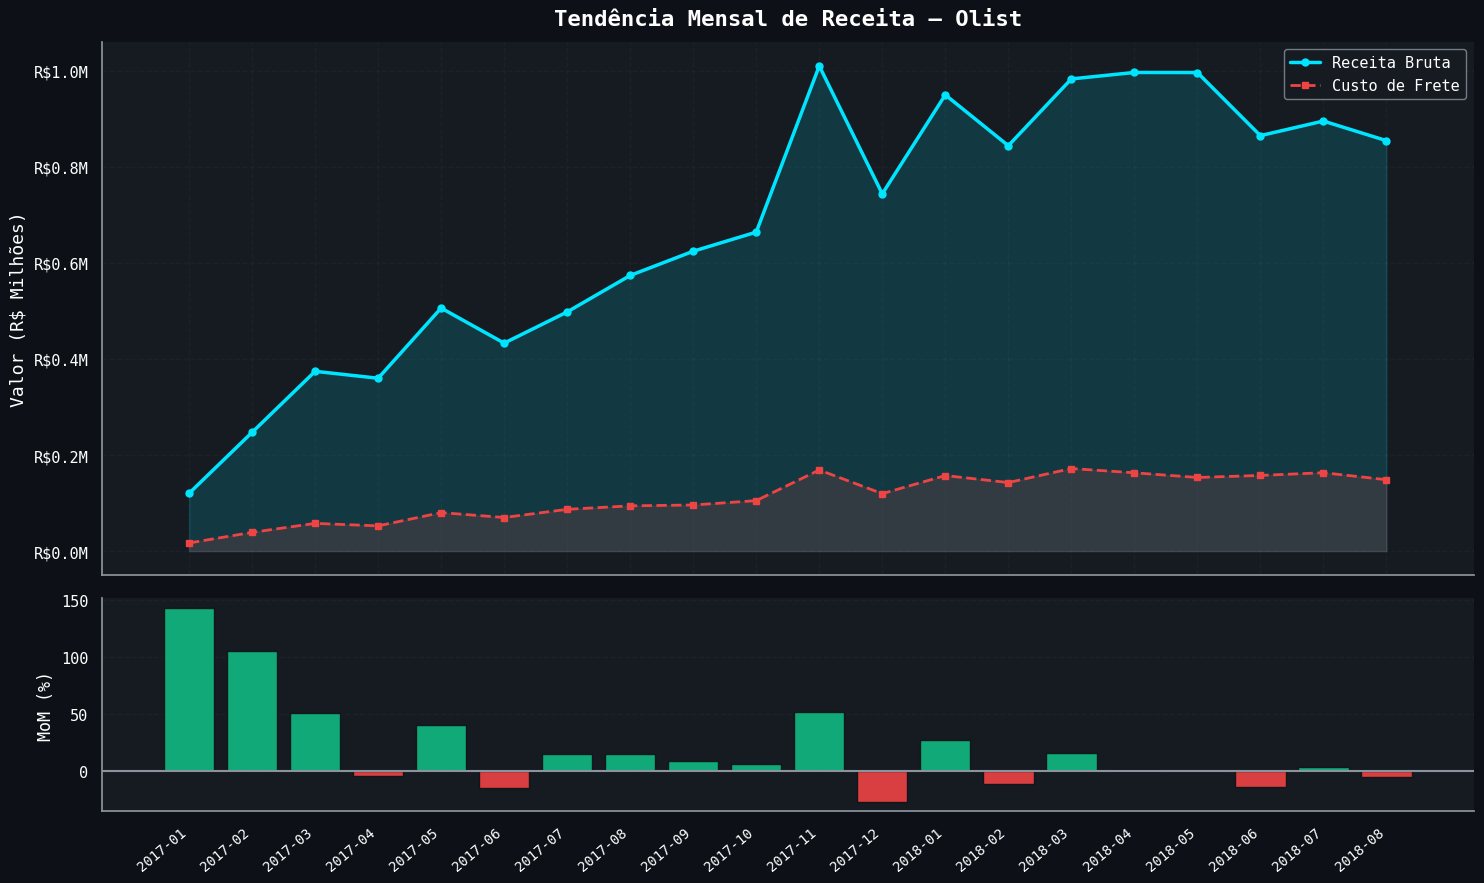

Figura 5 salva


In [ ]:
# ── FIGURA 5: Tendência Mensal ────────────────────────────────────────────────
df_m = monthly.dropna(subset=['mom_receita_pct']).copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                                gridspec_kw={'height_ratios': [2.5, 1]})
for a in [ax1, ax2]:
    a.set_facecolor('#161b22')
fig.patch.set_facecolor('#0d1117')

x = range(len(df_m))
ax1.fill_between(x, df_m['receita_bruta'] / 1e6, alpha=0.15, color=C_CYAN)
ax1.plot(x, df_m['receita_bruta'] / 1e6, color=C_CYAN, linewidth=2.5,
         marker='o', markersize=5, label='Receita Bruta')
ax1.fill_between(x, df_m['custo_frete_total'] / 1e6, alpha=0.15, color=C_RED)
ax1.plot(x, df_m['custo_frete_total'] / 1e6, color=C_RED, linewidth=2,
         linestyle='--', marker='s', markersize=4, label='Custo de Frete')

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v:.1f}M'))
ax1.set_ylabel('Valor (R$ Milhões)', fontsize=13, color='white')
ax1.set_title('Tendência Mensal de Receita — Olist',
              fontsize=16, fontweight='bold', color='white', pad=12)
ax1.tick_params(labelsize=11, colors='white')
ax1.legend(facecolor='#161b22', edgecolor='#8b949e', fontsize=11, labelcolor='white')
ax1.grid(alpha=0.25)

mom_colors = [C_GREEN if v >= 0 else C_RED for v in df_m['mom_receita_pct']]
ax2.bar(x, df_m['mom_receita_pct'], color=mom_colors, alpha=0.9, edgecolor='#0d1117')
ax2.axhline(0, color='#8b949e', linewidth=1.5)
ax2.set_ylabel('MoM (%)', fontsize=12, color='white')
ax2.tick_params(labelsize=11, colors='white')
ax2.grid(axis='y', alpha=0.25)

plt.xticks(x, df_m['mes'], rotation=40, ha='right', fontsize=10, color='white')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '05_tendencia_mensal.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura 5 salva')

In [ ]:
print(risk['status_financeiro'].value_counts())

status_financeiro
⚠️  Atenção     57
🚨 Alto Risco     1
✅ Saudável       1
Name: count, dtype: int64


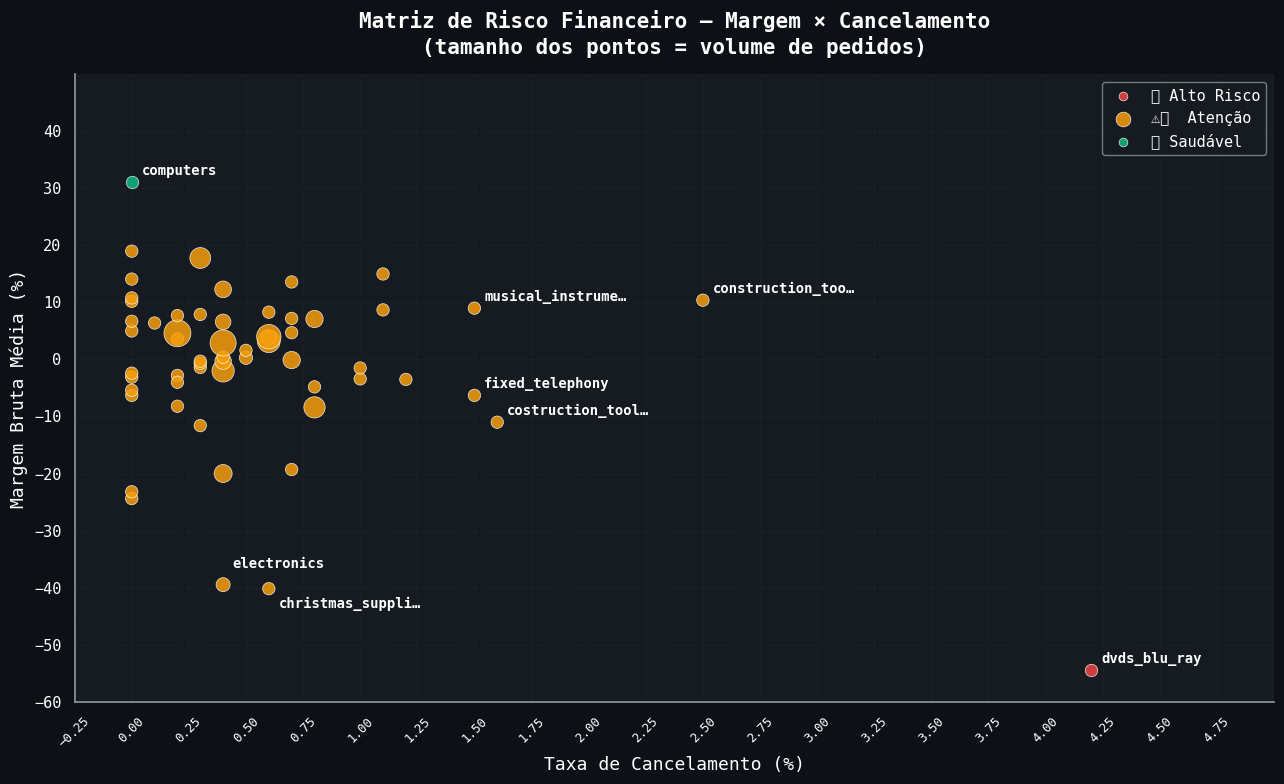

Figura 6 salva


In [ ]:
# ── FIGURA 6: Matriz de Risco ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

status_palette = {}
for s in risk['status_financeiro'].unique():
    if 'Alto' in s:
        status_palette[s] = C_RED
    elif 'Aten' in s:
        status_palette[s] = C_YELLOW
    elif 'Saud' in s:
        status_palette[s] = C_GREEN
    else:
        status_palette[s] = C_BLUE

for status, color in status_palette.items():
    mask = risk['status_financeiro'] == status
    sub  = risk[mask]
    ax.scatter(
        sub['cancel_rate_pct'],
        sub['margem_bruta_media_pct'],
        s=np.maximum(sub['total_orders'] / 25, 80),
        color=color, alpha=0.85,
        edgecolors='white', linewidths=0.5,
        label=status, marker='o',   # força círculo em todos
        zorder=3
    )

# Critério de anotação: outliers por cancelamento alto, margem muito negativa,
# margem muito positiva, ou status diferente de Atenção
cancel_thresh  = risk['cancel_rate_pct'].quantile(0.70)
margem_low     = risk['margem_bruta_media_pct'].quantile(0.12)

mask_label = (
    (risk['margem_bruta_media_pct'] < -30) |
    (risk['margem_bruta_media_pct'] > 20) |
    (risk['cancel_rate_pct'] > 1.25) |
    (~risk['status_financeiro'].str.contains('Aten'))
)
for _, row in risk[mask_label].iterrows():
    cat = row['category'][:16] + '…' if len(row['category']) > 16 else row['category']
    x_offset = 7
    y_offset = 5
    if 'christmas' in row['category'].lower():
        y_offset = -14
    elif 'electronics' in row['category'].lower():
        y_offset = 12
    ax.annotate(cat,
                xy=(row['cancel_rate_pct'], row['margem_bruta_media_pct']),
                xytext=(x_offset, y_offset), textcoords='offset points',
                fontsize=10, color='white', fontweight='bold')

ax.set_xlabel('Taxa de Cancelamento (%)', fontsize=13, color='white')
ax.set_ylabel('Margem Bruta Média (%)', fontsize=13, color='white')
ax.set_title('Matriz de Risco Financeiro — Margem × Cancelamento\n(tamanho dos pontos = volume de pedidos)',
             fontsize=15, fontweight='bold', color='white', pad=15)
ax.tick_params(labelsize=11, colors='white')
ax.legend(loc='upper right', facecolor='#161b22', edgecolor='#8b949e',
          fontsize=11, labelcolor='white', markerscale=0.7)
ax.grid(alpha=0.25)

ax.set_xlim(0, 5)
ax.set_xticks(np.arange(-0.25, 5.00, 0.25))
ax.tick_params(axis='x', labelsize=9, rotation=45)

ax.set_ylim(-50, 50)
ax.set_yticks(np.arange(-60, 41, 10))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '06_matriz_risco.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura 6 salva')

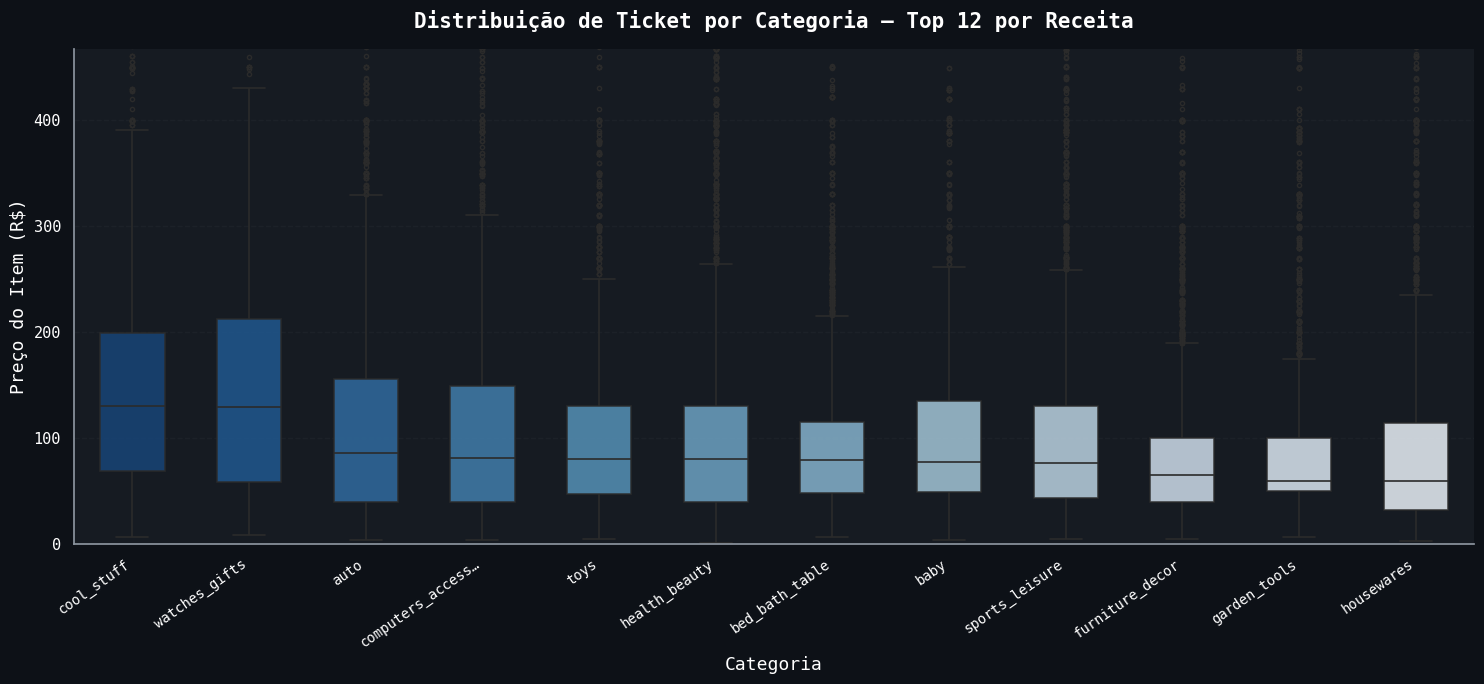

Figura 7 salva


In [ ]:
# ── FIGURA 7: Boxplot Ticket ──────────────────────────────────────────────────
top12_cats = dre.nlargest(12, 'receita_liquida')['category'].tolist()
df_box = metrics[metrics['category'].isin(top12_cats)].copy()
df_box['category_short'] = df_box['category'].apply(
    lambda c: c[:16] + '…' if len(c) > 16 else c
)
order = (df_box.groupby('category_short')['price']
         .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

sns.boxplot(
    data=df_box, x='category_short', y='price',
    order=order, palette='Blues_r',
    width=0.55, fliersize=3, linewidth=1.2,
    boxprops=dict(alpha=0.85),
    ax=ax
)

ax.set_xlabel('Categoria', fontsize=13, color='white')
ax.set_ylabel('Preço do Item (R$)', fontsize=13, color='white')
ax.set_title('Distribuição de Ticket por Categoria — Top 12 por Receita',
             fontsize=15, fontweight='bold', color='white', pad=15)
ax.set_ylim(0, df_box['price'].quantile(0.97))
ax.tick_params(axis='x', labelsize=10, colors='white', rotation=35)
ax.tick_params(axis='y', labelsize=11, colors='white')
plt.setp(ax.get_xticklabels(), ha='right')
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '07_boxplot_ticket.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura 7 salva')

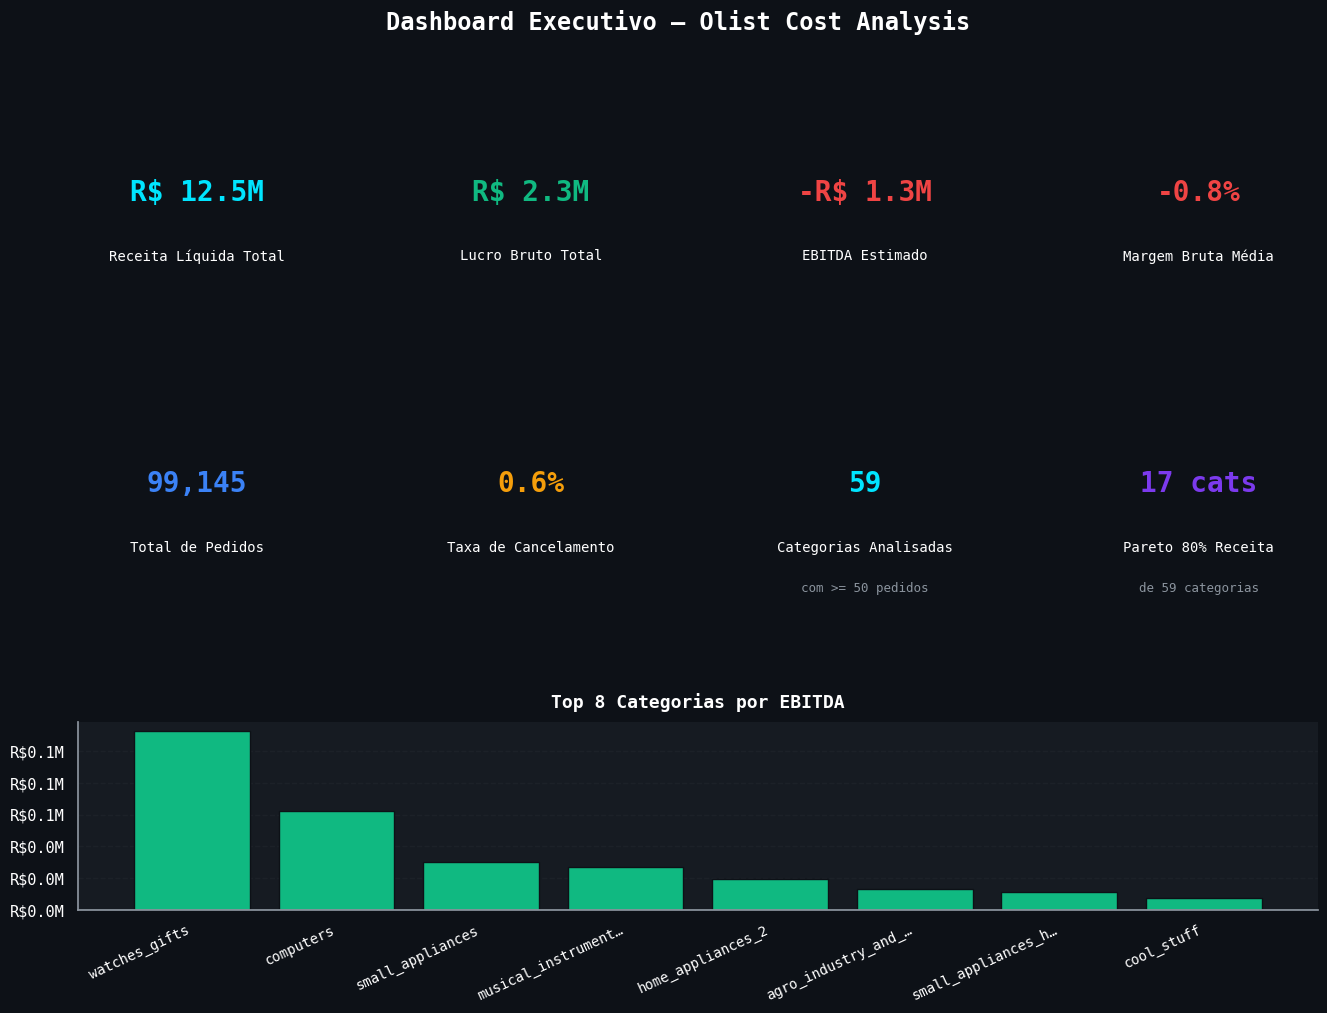

Figura 8 (Dashboard) salva


In [ ]:
# ── FIGURA 8: Dashboard Final ─────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
gs  = GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

def kpi_box(ax, title, value, subtitle='', color=C_CYAN):
    ax.set_facecolor('#161b22')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.72, value, ha='center', va='center',
            fontsize=20, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.38, title, ha='center', va='center',
            fontsize=10, color='white', transform=ax.transAxes)
    if subtitle:
        ax.text(0.5, 0.16, subtitle, ha='center', va='center',
                fontsize=9, color='#8b949e', transform=ax.transAxes)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
        spine.set_visible(True)

receita_total = dre['receita_liquida'].sum()
lucro_total   = dre['lucro_bruto'].sum()
ebitda_total  = dre['ebitda'].sum()
margem_media  = dre['margem_bruta_media_pct'].mean()
total_pedidos = dre['total_orders'].sum()
cancel_rate   = (dre['cancelled_orders'].sum() / dre['total_orders'].sum()) * 100
n_cats        = len(dre)
pareto_80_n   = len(pareto[pareto['participacao_acumulada_pct'] <= 80])

kpi_box(fig.add_subplot(gs[0,0]), 'Receita Líquida Total',
        f'R$ {receita_total/1e6:.1f}M', color=C_CYAN)
kpi_box(fig.add_subplot(gs[0,1]), 'Lucro Bruto Total',
        f'R$ {lucro_total/1e6:.1f}M', color=C_GREEN)
ebitda_color = C_GREEN if ebitda_total >= 0 else C_RED
ebitda_sign  = '-' if ebitda_total < 0 else ''
kpi_box(fig.add_subplot(gs[0,2]), 'EBITDA Estimado',
        f'{ebitda_sign}R$ {abs(ebitda_total)/1e6:.1f}M', color=ebitda_color)
margem_color = C_GREEN if margem_media >= 0 else C_RED
kpi_box(fig.add_subplot(gs[0,3]), 'Margem Bruta Média',
        f'{margem_media:.1f}%', color=margem_color)

kpi_box(fig.add_subplot(gs[1,0]), 'Total de Pedidos',
        f'{total_pedidos:,.0f}', color=C_BLUE)
cancel_color = C_RED if cancel_rate > 3 else C_YELLOW
kpi_box(fig.add_subplot(gs[1,1]), 'Taxa de Cancelamento',
        f'{cancel_rate:.1f}%', color=cancel_color)
kpi_box(fig.add_subplot(gs[1,2]), 'Categorias Analisadas',
        f'{n_cats}', 'com >= 50 pedidos', color=C_CYAN)
kpi_box(fig.add_subplot(gs[1,3]), 'Pareto 80% Receita',
        f'{pareto_80_n} cats', f'de {n_cats} categorias', color=C_PURPLE)

ax_bar = fig.add_subplot(gs[2, :])
ax_bar.set_facecolor('#161b22')
top8 = dre.nlargest(8, 'ebitda')
cats = [c[:18]+'…' if len(c)>18 else c for c in top8['category']]
bar_colors2 = [C_GREEN if v >= 0 else C_RED for v in top8['ebitda']]
ax_bar.bar(cats, top8['ebitda'] / 1e6, color=bar_colors2, edgecolor='#0d1117')
ax_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v:.1f}M'))
ax_bar.set_title('Top 8 Categorias por EBITDA',
                 fontsize=13, fontweight='bold', color='white', pad=10)
ax_bar.tick_params(axis='x', labelsize=10, colors='white', rotation=25)
ax_bar.tick_params(axis='y', labelsize=11, colors='white')
plt.setp(ax_bar.get_xticklabels(), ha='right')
ax_bar.grid(axis='y', alpha=0.25)
ax_bar.set_axisbelow(True)
ax_bar.axhline(0, color='#8b949e', linewidth=1)

fig.suptitle('Dashboard Executivo — Olist Cost Analysis',
             fontsize=17, fontweight='bold', color='white', y=1.01)

plt.savefig(os.path.join(FIGURES_PATH, '08_dashboard_final.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Figura 8 (Dashboard) salva')

In [ ]:
print('Todas as figuras geradas:')
for f in sorted(os.listdir(FIGURES_PATH)):
    if f.endswith('.png'):
        kb = os.path.getsize(os.path.join(FIGURES_PATH, f)) / 1024
        print(f'  {f:<50} {kb:6.0f} KB')
print('\nNotebook 04 concluído!')

Todas as figuras geradas:
  01_waterfall_dre.png                                   96 KB
  02_pareto_receita.png                                 203 KB
  03_quadrante_estrategico.png                          180 KB
  04_heatmap_correlacao.png                             241 KB
  05_tendencia_mensal.png                               149 KB
  06_matriz_risco.png                                   126 KB
  07_boxplot_ticket.png                                 149 KB
  08_dashboard_final.png                                163 KB
  09_model_evaluation.png                               189 KB
  10_feature_importance.png                              85 KB

Notebook 04 concluído!
